# Telco Customer Churn — Modeling & Evaluation

**Author:** Allison Schiltz\

**Objectives**:
- Build two models to predict `Churn`:
    - For both models: **Class weights** will be used adjust for imbalanced data and **regularization** will be used to prevent overfitting.
    - **Logistic Regression** with regularizataion as a baseline and for interpretability. A baseline model helps determine whether a more complex model adds value. 
    - **Gradient Boosted Trees** using LightGBM for higher predictive power
    - **Optuna** will be using for hyperparameter tuning and cross-validation
- **Strategy**: 
    - Use a train/test split strategy with cross-validation (CV) plus a final holdout set.
    - Perform cross-validation on the training data to tune hyperparameters.
    - Evaluate the final model on the untouched test set (holdout) for an unbiased performance estimate.
- Prioritize **recall ≥ 0.70** and **ROC-AUC > 0.75**
    - **Recall** to identify as many customers at risk of churning as possible (minimizing false negatives). This is important in churn scenarios, where missing a potential churner can be costly for the business.
    - **ROC-AUC** to measure the model’s overall discriminative power to distinguish between churners and non-churners across all thresholds.

## 0. Environment & Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import optuna.integration.lightgbm as lgb_optuna

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import recall_score, roc_auc_score, precision_score, confusion_matrix, roc_curve, precision_recall_curve, make_scorer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict

import lightgbm as lgb

SEED = 42
np.random.seed(SEED)

In [2]:
import sys
print(sys.executable)

/Users/Allison/Code/.venv/bin/python


## 1. Load Data
- Load combined, preprocessed features and target labels needed for modeling.
- Load column-role manifest (ID, target, numeric, categorical, booleans)

In [3]:
# Load Training features
X_train_final = pd.read_csv('../data/processed/X_train_final.csv')
# Load Training target
y_train = pd.read_csv('../data/processed/y_train.csv')

# Load Test features
X_test_final = pd.read_csv('../data/processed/X_test_final.csv')
# Load Test target
y_test = pd.read_csv('../data/processed/y_test.csv')

# Load column role manifest
column_roles = pd.read_csv('../references/telco_column_role_manifest.csv')

# Load pruned feature sets based on EDA findings
pruned_features_monthly_charges_bin = pd.read_csv('../data/processed/pruned_features_monthly_charges_bin.csv', header=None).squeeze().tolist()

pruned_features_internet_service = pd.read_csv('../data/processed/pruned_features_internet_service.csv', header=None).squeeze().tolist()

pruned_features_all_add_ons = pd.read_csv('../data/processed/pruned_features_all_add_ons.csv', header=None).squeeze().tolist()

In [4]:
# Clean column names to remove special JSON characters for LightGBM compatibility
import re

def clean_lgbm_feature_names(df):
    df = df.copy()
    df.columns = [
        re.sub(r'["\\{}\[\]:,]', '_', str(col)) for col in df.columns
    ]
    return df

# Cleaned versions for LightGBM
X_train_final_clean = clean_lgbm_feature_names(X_train_final)
X_test_final_clean = clean_lgbm_feature_names(X_test_final)


In [5]:
# Extract target column

y_train = y_train['Churn']
y_test = y_test['Churn']

In [6]:
print(X_train_final_clean.shape)
print(y_train.shape, '\n')

print(X_test_final_clean.shape)
print(y_test.shape)

(5625, 41)
(5625,) 

(1407, 41)
(1407,)


In [7]:
print(X_train_final_clean.head())
print(X_test_final_clean.head())
print(y_train.head())
print(y_test.head(), '\n')
print('X_train_final_clean dtypes:', X_train_final_clean.dtypes, '\n')
print('X_test_final_clean dtypes:', X_test_final_clean.dtypes, '\n')

   Unnamed_ 0    tenure  MonthlyCharges  TotalCharges  total_services_eng  \
0        1408  1.321816        0.981556      1.659900            1.269948   
1        6992 -0.267410       -0.971546     -0.562252           -0.671868   
2        3349  1.444064        0.837066      1.756104            0.784494   
3        4486 -1.204646        0.641092     -0.908326           -0.186414   
4        3535  0.669826       -0.808787     -0.101561           -0.671868   

   gender_Male  SeniorCitizen_Yes  Partner_Yes  Dependents_Yes  \
0         True              False         True            True   
1         True              False        False           False   
2        False              False         True           False   
3         True              False        False           False   
4        False              False         True           False   

   PhoneService_Yes  ...  PaymentMethod_Mailed_check  tenure_group_eng_13-24  \
0              True  ...                       False        

## 2. Baselines
1. Majority-class baseline:
- Predict the most frequent class for all cases (e.g., always predict "No Churn").
- Calculate and record metrics: recall, precision, ROC-AUC, PR-AUC. This sets a minimum performance bar.
2. Logistic regression baseline (with regularization):
- Train a logistic regression model using default or simple regularization (e.g., L2 penalty, class_weight="balanced").
- Evaluate on the validation or test set.
- Record the same metrics: recall, precision, ROC-AUC, PR-AUC.


### Majority class baseline: all features

In [8]:
# Majority class baseline with all features
from sklearn.dummy import DummyClassifier

# Instantiate and fit dummy classifier
dummy = DummyClassifier(strategy="stratified", random_state=SEED)
dummy.fit(X_train_final_clean, y_train.values.ravel())

# Predict class labels and class probabilities
y_pred_dummy = dummy.predict(X_test_final_clean)
y_proba_dummy = dummy.predict_proba(X_test_final_clean)[:, 1]

# Calculate and print metrics
print("Accuracy:", round(dummy.score(X_test_final_clean, y_test), 4))
print("Recall:", round(recall_score(y_test, y_pred_dummy), 4))
print("Precision:", round(precision_score(y_test, y_pred_dummy), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_dummy), 4))

Accuracy: 0.6148
Recall: 0.2781
Precision: 0.2766
ROC-AUC: 0.5074


### Logistic Regression Model: All features

In [9]:
# Logistic Regression Model with Regularization, Hyperparameter Tuning, and Class Weighting: All features

# Define parameter grid for hyperparameter tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10],           # Regularization strength
    'penalty': ['l2', 'l1'],                 # L1 and L2 regularization types
    'solver': ['liblinear'],               # 'liblinear' supports L1 and L2
    'class_weight': ['balanced']       # Handle class imbalance
}

# Set up logistic regression and grid search
logreg = LogisticRegression(max_iter=1000, random_state=SEED)
grid = GridSearchCV(logreg, param_grid, scoring='recall', cv=5, n_jobs=-1)

# Fit on training data
grid.fit(X_train_final_clean, y_train if isinstance(y_train, pd.Series) else y_train)

# Best model
best_logreg = grid.best_estimator_


In [10]:
print(best_logreg)

LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000,
                   random_state=42, solver='liblinear')


### Logistic Regression Model: Binned Montly Charges

In [11]:
# Logistic Regression Model with Regularization, Hyperparameter Tuning, and Class Weighting: Pruned features - Monthly Charges (no add-ons except Online Security)

# Subset the full training and test sets using the pruned feature list
X_train_monthly_charges_bin = X_train_final_clean[pruned_features_monthly_charges_bin]

# Define parameter grid for hyperparameter tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10],           # Regularization strength
    'penalty': ['l2', 'l1'],                 # L1 and L2 regularization types
    'solver': ['liblinear'],               # 'liblinear' supports L1 and L2
    'class_weight': ['balanced']       # Handle class imbalance
}

# Set up logistic regression and grid search
monthly_charges_logreg = LogisticRegression(max_iter=1000, random_state=SEED)
monthly_charges_grid = GridSearchCV(monthly_charges_logreg, param_grid, scoring='recall', cv=5, n_jobs=-1)

# Fit on training data
monthly_charges_grid.fit(X_train_monthly_charges_bin, y_train if isinstance(y_train, pd.Series) else y_train)

# Best model
best_logreg_monthly_charges_bin = monthly_charges_grid.best_estimator_



In [12]:
print("Best monthly charges hyperparam for log reg model:\n", best_logreg_monthly_charges_bin)

Best monthly charges hyperparam for log reg model:
 LogisticRegression(C=0.01, class_weight='balanced', max_iter=1000,
                   random_state=42, solver='liblinear')


### Logistic Regression Model: Internet Service (no add-ons except Online Security)

In [13]:
# Logistic Regression Model with Regularization, Hyperparameter Tuning, and Class Weighting: Pruned features - Internet Service (no add-ons except OnlineSecurity)

# Subset the full training and test sets using the pruned feature list
X_train_internet_service = X_train_final_clean[pruned_features_internet_service]

# Define parameter grid for hyperparameter tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10],           # Regularization strength
    'penalty': ['l2', 'l1'],                 # L1 and L2 regularization types
    'solver': ['liblinear'],               # 'liblinear' supports L1 and L2
    'class_weight': ['balanced']       # Handle class imbalance
}

# Set up logistic regression and grid search
internet_service_logreg = LogisticRegression(max_iter=1000, random_state=SEED)
internet_service_grid = GridSearchCV(internet_service_logreg, param_grid, scoring='recall', cv=5, n_jobs=-1)

# Fit on training data
internet_service_grid.fit(X_train_internet_service, y_train if isinstance(y_train, pd.Series) else y_train)

# Best model
best_logreg_internet_service = internet_service_grid.best_estimator_



In [14]:
print("Best logreg internet service hyperparameters:\n", best_logreg_internet_service)

Best logreg internet service hyperparameters:
 LogisticRegression(C=1, class_weight='balanced', max_iter=1000, random_state=42,
                   solver='liblinear')


### Logistic Regression Model: All Add-Ons, no Internet Service

In [15]:
# Logistic Regression Model with Regularization, Hyperparameter Tuning, and Class Weighting: Pruned features - All Add-Ons, no InternetService

# Subset the full training and test sets using the pruned feature list
X_train_all_add_ons = X_train_final_clean[pruned_features_all_add_ons]

# Define parameter grid for hyperparameter tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10],           # Regularization strength
    'penalty': ['l2', 'l1'],                 # L1 and L2 regularization types
    'solver': ['liblinear'],               # 'liblinear' supports L1 and L2
    'class_weight': ['balanced']       # Handle class imbalance
}

# Set up logistic regression and grid search
all_add_ons_logreg = LogisticRegression(max_iter=1000, random_state=SEED)
all_add_ons_grid = GridSearchCV(all_add_ons_logreg, param_grid, scoring='recall', cv=5, n_jobs=-1)

# Fit on training data
all_add_ons_grid.fit(X_train_all_add_ons, y_train if isinstance(y_train, pd.Series) else y_train)

# Best model
best_logreg_all_add_ons = all_add_ons_grid.best_estimator_


In [16]:
print("Best logreg all add ons hyperparameters:\n", best_logreg_all_add_ons)

Best logreg all add ons hyperparameters:
 LogisticRegression(C=1, class_weight='balanced', max_iter=1000, penalty='l1',
                   random_state=42, solver='liblinear')


### Evaluate best Logistic Regression Model: All features

In [17]:
# Evaluate the best Logistic Regression model using the best parameters
print("Results for All Features Model")
print("Best parameters:", grid.best_params_)
print("Mean cross-validated recall:", round(grid.best_score_, 4))

cv_precision = cross_val_score(best_logreg, X_train_final_clean, y_train, cv=5, scoring='precision')

print("Mean cross-validated precision:", round(cv_precision.mean(), 4))

cv_roc_auc = cross_val_score(best_logreg, X_train_final_clean, y_train, cv=5, scoring='roc_auc')

print("Mean cross-validated ROC-AUC:", round(cv_roc_auc.mean(), 4))

Results for All Features Model
Best parameters: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Mean cross-validated recall: 0.802
Mean cross-validated precision: 0.5262
Mean cross-validated ROC-AUC: 0.8479


### Evaluate Best Logistic Regression Model: Binned Monthly Charges

In [18]:
# Evaluate the best Logistic Regression model using the best parameters
print("Results for Pruned Monthly Charges Model")
print("Best parameters:", monthly_charges_grid.best_params_)
print("Mean cross-validated recall:", round(monthly_charges_grid.best_score_, 4))

monthly_charges_cv_precision = cross_val_score(best_logreg_monthly_charges_bin, X_train_monthly_charges_bin, y_train, cv=5, scoring='precision')

print("Mean cross-validated precision:", round(monthly_charges_cv_precision.mean(), 4))
monthly_charges_cv_roc_auc = cross_val_score(best_logreg_monthly_charges_bin, X_train_monthly_charges_bin, y_train, cv=5, scoring='roc_auc')

print("Mean cross-validated ROC-AUC:", round(monthly_charges_cv_roc_auc.mean(), 4))

Results for Pruned Monthly Charges Model
Best parameters: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Mean cross-validated recall: 0.8
Mean cross-validated precision: 0.5163
Mean cross-validated ROC-AUC: 0.8339


### Evaluate Best Logistic Regression Model: Internet Service plus Online Security Add-on

In [19]:
# Evaluate the best Logistic Regression model using the best parameters
print("Results for Internet Service Model")
print("Best parameters:", internet_service_grid.best_params_)
print("Mean cross-validated recall:", round(internet_service_grid.best_score_, 4))

internet_service_cv_precision = cross_val_score(best_logreg_internet_service, X_train_internet_service, y_train, cv=5, scoring='precision')
print("Mean cross-validated precision:", round(internet_service_cv_precision.mean(), 4))
internet_service_cv_roc_auc = cross_val_score(best_logreg_internet_service, X_train_internet_service, y_train, cv=5, scoring='roc_auc')
print("Mean cross-validated ROC-AUC:", round(internet_service_cv_roc_auc.mean(), 4))

Results for Internet Service Model
Best parameters: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Mean cross-validated recall: 0.804
Mean cross-validated precision: 0.5227
Mean cross-validated ROC-AUC: 0.8445


### Evaluate Best Logistic Regression Model: All Add-Ons, no Internet Service

In [20]:
# Evaluate the best Logistic Regression model using the best parameters
print("Results for All Add-Ons Model")
print("Best parameters:", all_add_ons_grid.best_params_)
print("Mean cross-validated recall:", round(all_add_ons_grid.best_score_, 4))

all_add_ons_cv_precision = cross_val_score(best_logreg_all_add_ons, X_train_all_add_ons, y_train, cv=5, scoring='precision')
print("Mean cross-validated precision:", round(all_add_ons_cv_precision.mean(), 4))
all_add_ons_cv_roc_auc = cross_val_score(best_logreg_all_add_ons, X_train_all_add_ons, y_train, cv=5, scoring='roc_auc')
print("Mean cross-validated ROC-AUC:", round(all_add_ons_cv_roc_auc.mean(), 4))

Results for All Add-Ons Model
Best parameters: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Mean cross-validated recall: 0.8094
Mean cross-validated precision: 0.529
Mean cross-validated ROC-AUC: 0.8469


## 4. Advanced Models
- Tree-based gradient boosting with LightGBM
- Hyperparameter tuning (Oputuna) with cross-validation
- Early stopping / model selection criteria

### LightGBM Hyperparameter Tuning: All features

In [21]:
# LightGBM Model with Optuna Hyperparameter Tuning with Cross-Validation

# Prepare data for LightGBM (no need for label column in features)
X = X_train_final_clean  # Use cleaned DataFrame
y = y_train

# Set up Optuna LightGBM parameters
params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'class_weight': 'balanced',
}

callbacks = [lgb.early_stopping(stopping_rounds=50, min_delta=0.0)]

# Run Optuna hyperparameter tuning with cross-validation
optuna_lgbm = lgb_optuna.LightGBMTunerCV(
    params,
    lgb.Dataset(X, label=y),
    folds=None,  # None uses StratifiedKFold by default
    show_progress_bar=True,
    num_boost_round=1000,
    seed=SEED,
    nfold=5,
    callbacks=callbacks
)
optuna_lgbm.run()


[I 2026-02-02 18:31:09,908] A new study created in memory with name: no-name-66f3bed1-6035-4759-9af5-bb642a14a35f
feature_fraction, val_score: -inf:   0%|          | 0/7 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.844429:  14%|#4        | 1/7 [00:03<00:18,  3.03s/it]

Early stopping, best iteration is:
[25]	valid's auc: 0.844429 + 0.00469507
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.845929:  29%|##8       | 2/7 [00:05<00:13,  2.67s/it]

Early stopping, best iteration is:
[21]	valid's auc: 0.845929 + 0.00456528
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.847109:  43%|####2     | 3/7 [00:06<00:08,  2.08s/it]

Early stopping, best iteration is:
[22]	valid's auc: 0.847109 + 0.00614192
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.847109:  57%|#####7    | 4/7 [00:08<00:05,  1.91s/it]

Early stopping, best iteration is:
[21]	valid's auc: 0.846445 + 0.00599438
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.847660:  71%|#######1  | 5/7 [00:12<00:05,  2.52s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.84766 + 0.00508612
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.847660:  86%|########5 | 6/7 [00:13<00:02,  2.14s/it]

Early stopping, best iteration is:
[19]	valid's auc: 0.844421 + 0.00433494
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.847660: 100%|##########| 7/7 [00:15<00:00,  2.19s/it]


Early stopping, best iteration is:
[36]	valid's auc: 0.844399 + 0.00396617


num_leaves, val_score: 0.847660:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.847660:   5%|5         | 1/20 [00:05<01:45,  5.54s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.842715 + 0.00466851
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.847660:  10%|#         | 2/20 [00:07<01:05,  3.66s/it]

Early stopping, best iteration is:
[20]	valid's auc: 0.845111 + 0.00475195
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848318:  15%|#5        | 3/20 [00:10<00:52,  3.09s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.848318 + 0.00441455
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.849861:  20%|##        | 4/20 [00:12<00:44,  2.75s/it]

Early stopping, best iteration is:
[47]	valid's auc: 0.849861 + 0.003552
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.849861:  25%|##5       | 5/20 [00:13<00:33,  2.26s/it]

Early stopping, best iteration is:
[47]	valid's auc: 0.849846 + 0.00395453
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850064:  30%|###       | 6/20 [00:15<00:26,  1.88s/it]

Early stopping, best iteration is:
[137]	valid's auc: 0.850064 + 0.00502315
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850064:  35%|###5      | 7/20 [00:30<01:21,  6.25s/it]

Early stopping, best iteration is:
[18]	valid's auc: 0.842881 + 0.00489188
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850064:  40%|####      | 8/20 [00:36<01:16,  6.38s/it]

Early stopping, best iteration is:
[20]	valid's auc: 0.842328 + 0.00479703
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850064:  45%|####5     | 9/20 [00:37<00:51,  4.69s/it]

Early stopping, best iteration is:
[137]	valid's auc: 0.850064 + 0.00502315
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850064:  50%|#####     | 10/20 [00:46<00:58,  5.88s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.842715 + 0.00466851
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850064:  55%|#####5    | 11/20 [00:52<00:52,  5.88s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.844826 + 0.00506146
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850064:  60%|######    | 12/20 [00:59<00:50,  6.36s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.84155 + 0.00412659
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850064:  65%|######5   | 13/20 [01:01<00:35,  5.03s/it]

Early stopping, best iteration is:
[18]	valid's auc: 0.845736 + 0.0044061
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850064:  70%|#######   | 14/20 [01:05<00:27,  4.57s/it]

Early stopping, best iteration is:
[21]	valid's auc: 0.842785 + 0.00520898
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850064:  75%|#######5  | 15/20 [01:06<00:17,  3.49s/it]

Early stopping, best iteration is:
[47]	valid's auc: 0.849861 + 0.003552
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850064:  80%|########  | 16/20 [01:07<00:10,  2.74s/it]

Early stopping, best iteration is:
[37]	valid's auc: 0.849744 + 0.00288089
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850064:  85%|########5 | 17/20 [01:08<00:07,  2.39s/it]

Early stopping, best iteration is:
[18]	valid's auc: 0.84709 + 0.00476907
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850064:  90%|######### | 18/20 [01:09<00:03,  1.98s/it]

Early stopping, best iteration is:
[53]	valid's auc: 0.849355 + 0.00426994
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850064:  95%|#########5| 19/20 [01:12<00:02,  2.21s/it]

Early stopping, best iteration is:
[20]	valid's auc: 0.844295 + 0.00439116
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850064: 100%|##########| 20/20 [01:16<00:00,  3.81s/it]


Early stopping, best iteration is:
[18]	valid's auc: 0.84709 + 0.00476907


bagging, val_score: 0.850064:   0%|          | 0/10 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.850064:  10%|#         | 1/10 [00:03<00:33,  3.76s/it]

Early stopping, best iteration is:
[101]	valid's auc: 0.849427 + 0.00476884
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.850064:  20%|##        | 2/10 [00:09<00:38,  4.77s/it]

Early stopping, best iteration is:
[168]	valid's auc: 0.849221 + 0.00412209
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.850064:  30%|###       | 3/10 [00:10<00:23,  3.35s/it]

Early stopping, best iteration is:
[111]	valid's auc: 0.848001 + 0.00493212
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.850064:  40%|####      | 4/10 [00:12<00:16,  2.70s/it]

Early stopping, best iteration is:
[111]	valid's auc: 0.849404 + 0.00536374
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.850064:  50%|#####     | 5/10 [00:14<00:11,  2.36s/it]

Early stopping, best iteration is:
[98]	valid's auc: 0.849624 + 0.00442401
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.850064:  60%|######    | 6/10 [00:16<00:08,  2.19s/it]

Early stopping, best iteration is:
[105]	valid's auc: 0.849372 + 0.00504195
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.850064:  70%|#######   | 7/10 [00:19<00:07,  2.45s/it]

Early stopping, best iteration is:
[150]	valid's auc: 0.849479 + 0.00470456
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.850064:  80%|########  | 8/10 [00:21<00:04,  2.28s/it]

Early stopping, best iteration is:
[124]	valid's auc: 0.850001 + 0.00450325
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.850064:  90%|######### | 9/10 [00:22<00:02,  2.11s/it]

Early stopping, best iteration is:
[112]	valid's auc: 0.849691 + 0.00542016
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.850064: 100%|##########| 10/10 [00:24<00:00,  2.45s/it]


Early stopping, best iteration is:
[95]	valid's auc: 0.849102 + 0.00422414


feature_fraction_stage2, val_score: 0.850064:   0%|          | 0/3 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.850064:  33%|###3      | 1/3 [00:02<00:04,  2.19s/it]

Early stopping, best iteration is:
[172]	valid's auc: 0.849334 + 0.00474193
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.850064:  67%|######6   | 2/3 [00:04<00:02,  2.09s/it]

Early stopping, best iteration is:
[144]	valid's auc: 0.849865 + 0.00497808
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.850064: 100%|##########| 3/3 [00:06<00:00,  2.18s/it]


Early stopping, best iteration is:
[161]	valid's auc: 0.849826 + 0.00433205


regularization_factors, val_score: 0.850064:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850064:   5%|5         | 1/20 [00:02<00:40,  2.14s/it]

Early stopping, best iteration is:
[127]	valid's auc: 0.849706 + 0.00471909
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850064:  10%|#         | 2/20 [00:05<00:53,  2.97s/it]

Early stopping, best iteration is:
[207]	valid's auc: 0.849725 + 0.0044204
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850064:  15%|#5        | 3/20 [00:11<01:10,  4.14s/it]

Early stopping, best iteration is:
[137]	valid's auc: 0.850064 + 0.00502315
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850064:  20%|##        | 4/20 [00:14<00:58,  3.67s/it]

Early stopping, best iteration is:
[137]	valid's auc: 0.850064 + 0.00502315
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850064:  25%|##5       | 5/20 [00:17<00:53,  3.58s/it]

Early stopping, best iteration is:
[137]	valid's auc: 0.850064 + 0.00502315
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850064:  30%|###       | 6/20 [00:19<00:40,  2.92s/it]

Early stopping, best iteration is:
[137]	valid's auc: 0.850064 + 0.00502315
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850064:  35%|###5      | 7/20 [00:20<00:32,  2.50s/it]

Early stopping, best iteration is:
[137]	valid's auc: 0.850064 + 0.00502315
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850064:  40%|####      | 8/20 [00:22<00:26,  2.24s/it]

Early stopping, best iteration is:
[137]	valid's auc: 0.850064 + 0.00502315
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850064:  45%|####5     | 9/20 [00:24<00:22,  2.07s/it]

Early stopping, best iteration is:
[137]	valid's auc: 0.850064 + 0.00502315
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850064:  50%|#####     | 10/20 [00:25<00:19,  1.94s/it]

Early stopping, best iteration is:
[137]	valid's auc: 0.850064 + 0.00502315
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850064:  55%|#####5    | 11/20 [00:27<00:16,  1.89s/it]

Early stopping, best iteration is:
[143]	valid's auc: 0.850007 + 0.00507489
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850064:  60%|######    | 12/20 [00:29<00:14,  1.81s/it]

Early stopping, best iteration is:
[137]	valid's auc: 0.850064 + 0.00502315
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850064:  65%|######5   | 13/20 [00:34<00:19,  2.77s/it]

Early stopping, best iteration is:
[137]	valid's auc: 0.850064 + 0.00502315
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850064:  70%|#######   | 14/20 [00:38<00:18,  3.08s/it]

Early stopping, best iteration is:
[137]	valid's auc: 0.850064 + 0.00502315
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850064:  75%|#######5  | 15/20 [00:39<00:13,  2.70s/it]

Early stopping, best iteration is:
[137]	valid's auc: 0.850064 + 0.00502315
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850064:  80%|########  | 16/20 [00:41<00:09,  2.40s/it]

Early stopping, best iteration is:
[129]	valid's auc: 0.849972 + 0.00497897
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850064:  85%|########5 | 17/20 [00:43<00:06,  2.15s/it]

Early stopping, best iteration is:
[137]	valid's auc: 0.850064 + 0.00502315
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850064:  90%|######### | 18/20 [00:45<00:04,  2.07s/it]

Early stopping, best iteration is:
[137]	valid's auc: 0.850064 + 0.00502315
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850064:  95%|#########5| 19/20 [00:48<00:02,  2.54s/it]

Early stopping, best iteration is:
[143]	valid's auc: 0.849941 + 0.0050081
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.850064: 100%|##########| 20/20 [00:50<00:00,  2.52s/it]


Early stopping, best iteration is:
[137]	valid's auc: 0.850064 + 0.00502315


min_child_samples, val_score: 0.850064:   0%|          | 0/5 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.850064:  20%|##        | 1/5 [00:01<00:07,  1.78s/it]

Early stopping, best iteration is:
[144]	valid's auc: 0.849284 + 0.0047198
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.850064:  40%|####      | 2/5 [00:03<00:05,  1.93s/it]

Early stopping, best iteration is:
[176]	valid's auc: 0.849763 + 0.00508477
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.850064:  60%|######    | 3/5 [00:06<00:04,  2.30s/it]

Early stopping, best iteration is:
[136]	valid's auc: 0.849941 + 0.00481787
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.850131:  80%|########  | 4/5 [00:08<00:02,  2.02s/it]

Early stopping, best iteration is:
[137]	valid's auc: 0.850131 + 0.00465448
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.850131: 100%|##########| 5/5 [00:09<00:00,  1.91s/it]

Early stopping, best iteration is:
[150]	valid's auc: 0.84992 + 0.00476237


In [22]:
# Get best parameters and best score for LightGBM for All features
print('LightGBM: All features')
print('Best params:', optuna_lgbm.best_params)

# Cross-validated recall, precision, and ROC-AUC for LightGBM (using best Optuna params)
best_lgbm = lgb.LGBMClassifier(**optuna_lgbm.best_params, random_state=SEED)
cv_recall = cross_val_score(best_lgbm, X_train_final_clean, y_train, cv=5, scoring='recall')
cv_precision = cross_val_score(best_lgbm, X_train_final_clean, y_train, cv=5, scoring='precision')
cv_roc_auc = cross_val_score(best_lgbm, X_train_final_clean, y_train, cv=5, scoring='roc_auc')
print('Mean cross-validated recall:', round(cv_recall.mean(), 4))
print('Mean cross-validated precision:', round(cv_precision.mean(), 4))
print('Mean cross-validated ROC-AUC:', round(cv_roc_auc.mean(), 4))

LightGBM: All features
Best params: {'objective': 'binary', 'metric': 'auc', 'verbosity': -1, 'boosting_type': 'gbdt', 'class_weight': 'balanced', 'feature_pre_filter': False, 'lambda_l1': 0.0, 'lambda_l2': 0.0, 'num_leaves': 3, 'feature_fraction': 0.4, 'bagging_fraction': 1.0, 'bagging_freq': 0, 'min_child_samples': 10}
Mean cross-validated recall: 0.8114
Mean cross-validated precision: 0.5139
Mean cross-validated ROC-AUC: 0.8459


### LightGBM Model: Monthy Charges Pruned Feature Set


In [23]:
# Create pruned feature set for Monthly Charges
X_train_monthly_charges =  X_train_final_clean[pruned_features_monthly_charges_bin]
y = y_train

params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'class_weight': 'balanced',
}

callbacks = [lgb.early_stopping(stopping_rounds=50, min_delta=0.0)]

optuna_lgbm_monthly_charges = lgb_optuna.LightGBMTunerCV(
    params,
    lgb.Dataset(X_train_monthly_charges, label=y),
    folds=None,  # None uses StratifiedKFold by default
    show_progress_bar=True,
    num_boost_round=1000,
    seed=SEED,
    nfold=5,
    callbacks=callbacks
)
optuna_lgbm_monthly_charges.run()


[I 2026-02-02 18:34:13,644] A new study created in memory with name: no-name-2e4c0d1d-0b36-459f-aa58-be31c476d8c5
  0%|          | 0/7 [00:00<?, ?it/s]

feature_fraction, val_score: -inf:   0%|          | 0/7 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.838618:  14%|#4        | 1/7 [00:03<00:21,  3.50s/it]

Early stopping, best iteration is:
[15]	valid's auc: 0.838618 + 0.00859176
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.840054:  29%|##8       | 2/7 [00:06<00:16,  3.24s/it]

Early stopping, best iteration is:
[16]	valid's auc: 0.840054 + 0.00799637
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.840054:  43%|####2     | 3/7 [00:10<00:14,  3.72s/it]

Early stopping, best iteration is:
[38]	valid's auc: 0.839316 + 0.00848273
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.840203:  57%|#####7    | 4/7 [00:13<00:10,  3.42s/it]

Early stopping, best iteration is:
[14]	valid's auc: 0.840203 + 0.00917435
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.840203:  71%|#######1  | 5/7 [00:16<00:06,  3.24s/it]

Early stopping, best iteration is:
[58]	valid's auc: 0.839946 + 0.00888216
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.840203:  86%|########5 | 6/7 [00:18<00:02,  2.65s/it]

Early stopping, best iteration is:
[20]	valid's auc: 0.839769 + 0.00849886
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.840594: 100%|##########| 7/7 [00:20<00:00,  2.97s/it]


Early stopping, best iteration is:
[18]	valid's auc: 0.840594 + 0.00920103


num_leaves, val_score: 0.840594:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.840594:   5%|5         | 1/20 [00:07<02:20,  7.37s/it]

Early stopping, best iteration is:
[6]	valid's auc: 0.838784 + 0.00976416
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.840594:  10%|#         | 2/20 [00:17<02:40,  8.91s/it]

Early stopping, best iteration is:
[6]	valid's auc: 0.838784 + 0.00976416
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.840594:  15%|#5        | 3/20 [00:26<02:30,  8.86s/it]

Early stopping, best iteration is:
[6]	valid's auc: 0.838784 + 0.00976416
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.842425:  20%|##        | 4/20 [00:28<01:41,  6.34s/it]

Early stopping, best iteration is:
[58]	valid's auc: 0.842425 + 0.00841625
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.842425:  25%|##5       | 5/20 [00:34<01:32,  6.20s/it]

Early stopping, best iteration is:
[58]	valid's auc: 0.842425 + 0.00841625
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.842425:  30%|###       | 6/20 [00:37<01:10,  5.01s/it]

Early stopping, best iteration is:
[16]	valid's auc: 0.84065 + 0.00865101
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.842693:  35%|###5      | 7/20 [00:39<00:52,  4.00s/it]

Early stopping, best iteration is:
[68]	valid's auc: 0.842693 + 0.0086764
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.842693:  40%|####      | 8/20 [00:41<00:40,  3.36s/it]

Early stopping, best iteration is:
[6]	valid's auc: 0.840065 + 0.0100407
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.842693:  45%|####5     | 9/20 [00:44<00:37,  3.42s/it]

Early stopping, best iteration is:
[6]	valid's auc: 0.838784 + 0.00976416
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.842693:  50%|#####     | 10/20 [00:49<00:39,  3.91s/it]

Early stopping, best iteration is:
[6]	valid's auc: 0.839575 + 0.00968915
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.842693:  55%|#####5    | 11/20 [00:57<00:45,  5.02s/it]

Early stopping, best iteration is:
[11]	valid's auc: 0.839049 + 0.00919786
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.842693:  60%|######    | 12/20 [00:59<00:32,  4.06s/it]

Early stopping, best iteration is:
[94]	valid's auc: 0.842463 + 0.00806052
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.842693:  65%|######5   | 13/20 [01:06<00:35,  5.13s/it]

Early stopping, best iteration is:
[6]	valid's auc: 0.838796 + 0.00976858
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.842693:  70%|#######   | 14/20 [01:12<00:31,  5.27s/it]

Early stopping, best iteration is:
[6]	valid's auc: 0.839819 + 0.0100642
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.842693:  75%|#######5  | 15/20 [01:17<00:25,  5.12s/it]

Early stopping, best iteration is:
[94]	valid's auc: 0.842463 + 0.00806052
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.842693:  80%|########  | 16/20 [01:19<00:17,  4.29s/it]

Early stopping, best iteration is:
[66]	valid's auc: 0.842203 + 0.00832388
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.842693:  85%|########5 | 17/20 [01:23<00:12,  4.13s/it]

Early stopping, best iteration is:
[11]	valid's auc: 0.840362 + 0.00921773
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844536:  90%|######### | 18/20 [01:25<00:07,  3.62s/it]

Early stopping, best iteration is:
[436]	valid's auc: 0.844536 + 0.00765575
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844536:  95%|#########5| 19/20 [01:29<00:03,  3.64s/it]

Early stopping, best iteration is:
[6]	valid's auc: 0.839593 + 0.00967739
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844536: 100%|##########| 20/20 [01:39<00:00,  4.98s/it]


Early stopping, best iteration is:
[6]	valid's auc: 0.838784 + 0.00976416


bagging, val_score: 0.844536:   0%|          | 0/10 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844536:  10%|#         | 1/10 [00:02<00:23,  2.63s/it]

Early stopping, best iteration is:
[356]	valid's auc: 0.844031 + 0.00761388
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844536:  20%|##        | 2/10 [00:04<00:19,  2.45s/it]

Early stopping, best iteration is:
[343]	valid's auc: 0.844188 + 0.00751668
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844536:  30%|###       | 3/10 [00:07<00:17,  2.44s/it]

Early stopping, best iteration is:
[364]	valid's auc: 0.843938 + 0.0074694
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844536:  40%|####      | 4/10 [00:09<00:14,  2.46s/it]

Early stopping, best iteration is:
[357]	valid's auc: 0.844188 + 0.00746648
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844536:  50%|#####     | 5/10 [00:12<00:12,  2.52s/it]

Early stopping, best iteration is:
[357]	valid's auc: 0.844197 + 0.00749374
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844744:  60%|######    | 6/10 [00:19<00:15,  3.93s/it]

Early stopping, best iteration is:
[518]	valid's auc: 0.844744 + 0.00783258
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844744:  70%|#######   | 7/10 [00:24<00:12,  4.28s/it]

Early stopping, best iteration is:
[308]	valid's auc: 0.844263 + 0.00758959
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844744:  80%|########  | 8/10 [00:37<00:14,  7.13s/it]

Early stopping, best iteration is:
[240]	valid's auc: 0.844148 + 0.00836492
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844744:  90%|######### | 9/10 [00:42<00:06,  6.61s/it]

Early stopping, best iteration is:
[308]	valid's auc: 0.844427 + 0.0076729
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844744: 100%|##########| 10/10 [00:45<00:00,  4.51s/it]


Early stopping, best iteration is:
[201]	valid's auc: 0.843607 + 0.00834665


feature_fraction_stage2, val_score: 0.844744:   0%|          | 0/6 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844744:  17%|#6        | 1/6 [00:03<00:18,  3.69s/it]

Early stopping, best iteration is:
[518]	valid's auc: 0.844725 + 0.00797705
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844744:  33%|###3      | 2/6 [00:08<00:16,  4.11s/it]

Early stopping, best iteration is:
[440]	valid's auc: 0.844469 + 0.00764168
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844744:  50%|#####     | 3/6 [00:11<00:11,  3.99s/it]

Early stopping, best iteration is:
[452]	valid's auc: 0.844591 + 0.00770558
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844744:  67%|######6   | 4/6 [00:19<00:10,  5.36s/it]

Early stopping, best iteration is:
[518]	valid's auc: 0.844684 + 0.00798321
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844744:  83%|########3 | 5/6 [00:30<00:07,  7.25s/it]

Early stopping, best iteration is:
[518]	valid's auc: 0.844744 + 0.00783258
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844744: 100%|##########| 6/6 [00:35<00:00,  5.87s/it]


Early stopping, best iteration is:
[518]	valid's auc: 0.844725 + 0.00797705


regularization_factors, val_score: 0.844744:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844744:   5%|5         | 1/20 [00:05<01:37,  5.15s/it]

Early stopping, best iteration is:
[518]	valid's auc: 0.844744 + 0.00783258
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844744:  10%|#         | 2/20 [00:21<03:36, 12.01s/it]

Early stopping, best iteration is:
[518]	valid's auc: 0.844744 + 0.00783258
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844744:  15%|#5        | 3/20 [00:38<03:57, 13.98s/it]

Early stopping, best iteration is:
[518]	valid's auc: 0.844744 + 0.00783258
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844744:  20%|##        | 4/20 [00:51<03:36, 13.51s/it]

Early stopping, best iteration is:
[518]	valid's auc: 0.844744 + 0.00783258
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844744:  25%|##5       | 5/20 [00:56<02:40, 10.71s/it]

Early stopping, best iteration is:
[518]	valid's auc: 0.844744 + 0.00783258
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844744:  30%|###       | 6/20 [00:59<01:53,  8.07s/it]

Early stopping, best iteration is:
[518]	valid's auc: 0.844744 + 0.00783258
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844744:  35%|###5      | 7/20 [01:03<01:25,  6.61s/it]

Early stopping, best iteration is:
[518]	valid's auc: 0.844744 + 0.00783258
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844744:  40%|####      | 8/20 [01:07<01:10,  5.91s/it]

Early stopping, best iteration is:
[518]	valid's auc: 0.844742 + 0.00795207
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844744:  45%|####5     | 9/20 [01:11<00:57,  5.23s/it]

Early stopping, best iteration is:
[518]	valid's auc: 0.844744 + 0.00783258
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844744:  50%|#####     | 10/20 [01:39<02:03, 12.34s/it]

Early stopping, best iteration is:
[518]	valid's auc: 0.844744 + 0.00783258
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844744:  55%|#####5    | 11/20 [01:43<01:28,  9.79s/it]

Early stopping, best iteration is:
[518]	valid's auc: 0.844744 + 0.00783258
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844744:  60%|######    | 12/20 [01:46<01:00,  7.60s/it]

Early stopping, best iteration is:
[358]	valid's auc: 0.844214 + 0.00743054
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844752:  65%|######5   | 13/20 [01:51<00:47,  6.75s/it]

Early stopping, best iteration is:
[518]	valid's auc: 0.844752 + 0.00783691
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844752:  70%|#######   | 14/20 [01:55<00:35,  5.99s/it]

Early stopping, best iteration is:
[518]	valid's auc: 0.844752 + 0.00783691
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844755:  75%|#######5  | 15/20 [02:04<00:34,  6.94s/it]

Early stopping, best iteration is:
[518]	valid's auc: 0.844755 + 0.00784233
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844755:  80%|########  | 16/20 [02:10<00:26,  6.55s/it]

Early stopping, best iteration is:
[518]	valid's auc: 0.844746 + 0.00784923
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844755:  85%|########5 | 17/20 [02:13<00:16,  5.47s/it]

Early stopping, best iteration is:
[518]	valid's auc: 0.844744 + 0.00784998
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844755:  90%|######### | 18/20 [02:16<00:09,  4.90s/it]

Early stopping, best iteration is:
[518]	valid's auc: 0.844755 + 0.00784233
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844755:  95%|#########5| 19/20 [02:20<00:04,  4.52s/it]

Early stopping, best iteration is:
[518]	valid's auc: 0.844755 + 0.00784233
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844755: 100%|##########| 20/20 [02:28<00:00,  7.42s/it]


Early stopping, best iteration is:
[518]	valid's auc: 0.844755 + 0.00784233


min_child_samples, val_score: 0.844755:   0%|          | 0/5 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.844755:  20%|##        | 1/5 [00:03<00:14,  3.66s/it]

Early stopping, best iteration is:
[518]	valid's auc: 0.844755 + 0.00784233
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.844755:  40%|####      | 2/5 [00:07<00:10,  3.47s/it]

Early stopping, best iteration is:
[518]	valid's auc: 0.844755 + 0.00784233
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.844755:  60%|######    | 3/5 [00:10<00:06,  3.48s/it]

Early stopping, best iteration is:
[518]	valid's auc: 0.844755 + 0.00784233
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.844755:  80%|########  | 4/5 [00:14<00:03,  3.68s/it]

Early stopping, best iteration is:
[518]	valid's auc: 0.844755 + 0.00784233
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.844755: 100%|##########| 5/5 [00:16<00:00,  3.32s/it]

Early stopping, best iteration is:
[518]	valid's auc: 0.844755 + 0.00784233


In [24]:
# Get best parameters and best score for LightGBM monthly charges model

print('LightGBM monthly charges model')
print('Best params:', optuna_lgbm_monthly_charges.best_params)

# Cross-validated recall, precision, and ROC-AUC for LightGBM (using best Optuna params)
best_lgbm_monthly_charges = lgb.LGBMClassifier(**optuna_lgbm_monthly_charges.best_params, random_state=SEED)

cv_recall_monthly_charges = cross_val_score(best_lgbm_monthly_charges, X_train_monthly_charges, y_train, cv=5, scoring='recall')

cv_precision_monthly_charges = cross_val_score(best_lgbm_monthly_charges, X_train_monthly_charges, y_train, cv=5, scoring='precision')

cv_roc_auc_monthly_charges = cross_val_score(best_lgbm_monthly_charges, X_train_monthly_charges, y_train, cv=5, scoring='roc_auc')

print('Mean cross-validated recall:', round(cv_recall_monthly_charges.mean(), 4))
print('Mean cross-validated precision:', round(cv_precision_monthly_charges.mean(), 4))
print('Mean cross-validated ROC-AUC:', round(cv_roc_auc_monthly_charges.mean(), 4))

LightGBM monthly charges model
Best params: {'objective': 'binary', 'metric': 'auc', 'verbosity': -1, 'boosting_type': 'gbdt', 'class_weight': 'balanced', 'feature_pre_filter': False, 'lambda_l1': 0.008036415209802278, 'lambda_l2': 1.103495904660427e-08, 'num_leaves': 2, 'feature_fraction': 0.8, 'bagging_fraction': 0.6900555492867788, 'bagging_freq': 2, 'min_child_samples': 20}


Mean cross-validated recall: 0.8161
Mean cross-validated precision: 0.5022
Mean cross-validated ROC-AUC: 0.8364


### LightGBM Model: Internet Service Pruned Feature Set

In [25]:
X_train_internet_service =  X_train_final_clean[pruned_features_internet_service] # Create pruned feature set for Monthly Charges

y = y_train

params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'class_weight': 'balanced',
}

callbacks = [lgb.early_stopping(stopping_rounds=50, min_delta=0.0)]

optuna_lgbm_internet_service = lgb_optuna.LightGBMTunerCV(
    params,
    lgb.Dataset(X_train_internet_service, label=y),
    folds=None,  # None uses StratifiedKFold by default
    show_progress_bar=True,
    num_boost_round=1000,
    seed=SEED,
    nfold=5,
    callbacks=callbacks
)
optuna_lgbm_internet_service.run()


[I 2026-02-02 18:40:20,300] A new study created in memory with name: no-name-51f3cd34-6fd0-458c-a586-a2ff610940cb
feature_fraction, val_score: -inf:   0%|          | 0/7 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.839234:  14%|#4        | 1/7 [00:01<00:10,  1.81s/it]

Early stopping, best iteration is:
[10]	valid's auc: 0.839234 + 0.0103139
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.839234:  29%|##8       | 2/7 [00:03<00:09,  1.87s/it]

Early stopping, best iteration is:
[43]	valid's auc: 0.837897 + 0.00882177
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.839234:  43%|####2     | 3/7 [00:05<00:07,  1.80s/it]

Early stopping, best iteration is:
[46]	valid's auc: 0.836495 + 0.00923247
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.839554:  57%|#####7    | 4/7 [00:06<00:04,  1.45s/it]

Early stopping, best iteration is:
[18]	valid's auc: 0.839554 + 0.00952429
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.839554:  71%|#######1  | 5/7 [00:07<00:02,  1.47s/it]

Early stopping, best iteration is:
[59]	valid's auc: 0.836462 + 0.00895202
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.841138:  86%|########5 | 6/7 [00:09<00:01,  1.36s/it]

Early stopping, best iteration is:
[19]	valid's auc: 0.841138 + 0.00869123
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.841619: 100%|##########| 7/7 [00:11<00:00,  1.66s/it]


Early stopping, best iteration is:
[22]	valid's auc: 0.841619 + 0.00884165


num_leaves, val_score: 0.841619:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.841619:   5%|5         | 1/20 [00:01<00:29,  1.57s/it]

Early stopping, best iteration is:
[14]	valid's auc: 0.836575 + 0.0102803
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.841619:  10%|#         | 2/20 [00:04<00:43,  2.40s/it]

Early stopping, best iteration is:
[13]	valid's auc: 0.833499 + 0.010835
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.841619:  15%|#5        | 3/20 [00:07<00:44,  2.63s/it]

Early stopping, best iteration is:
[13]	valid's auc: 0.833806 + 0.0104838
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.841619:  20%|##        | 4/20 [00:11<00:50,  3.15s/it]

Early stopping, best iteration is:
[13]	valid's auc: 0.833497 + 0.0108342
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.843714:  25%|##5       | 5/20 [00:12<00:35,  2.38s/it]

Early stopping, best iteration is:
[27]	valid's auc: 0.843714 + 0.00808495
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.843714:  30%|###       | 6/20 [00:14<00:30,  2.16s/it]

Early stopping, best iteration is:
[53]	valid's auc: 0.842734 + 0.00902779
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844147:  35%|###5      | 7/20 [00:18<00:38,  2.93s/it]

Early stopping, best iteration is:
[27]	valid's auc: 0.844147 + 0.00895017
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844147:  40%|####      | 8/20 [00:20<00:29,  2.43s/it]

Early stopping, best iteration is:
[121]	valid's auc: 0.843662 + 0.00882301
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844147:  45%|####5     | 9/20 [00:23<00:29,  2.65s/it]

Early stopping, best iteration is:
[14]	valid's auc: 0.837137 + 0.0100025
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844147:  50%|#####     | 10/20 [00:34<00:52,  5.30s/it]

Early stopping, best iteration is:
[22]	valid's auc: 0.839139 + 0.00870838
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844147:  55%|#####5    | 11/20 [00:37<00:41,  4.64s/it]

Early stopping, best iteration is:
[14]	valid's auc: 0.833041 + 0.0105114
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844147:  60%|######    | 12/20 [00:46<00:46,  5.84s/it]

Early stopping, best iteration is:
[13]	valid's auc: 0.834106 + 0.0104983
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844147:  65%|######5   | 13/20 [00:50<00:37,  5.42s/it]

Early stopping, best iteration is:
[13]	valid's auc: 0.833497 + 0.0108342
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844147:  70%|#######   | 14/20 [00:51<00:24,  4.15s/it]

Early stopping, best iteration is:
[22]	valid's auc: 0.841619 + 0.00884165
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844147:  75%|#######5  | 15/20 [00:52<00:15,  3.12s/it]

Early stopping, best iteration is:
[121]	valid's auc: 0.843662 + 0.00882301
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844147:  80%|########  | 16/20 [00:54<00:10,  2.67s/it]

Early stopping, best iteration is:
[371]	valid's auc: 0.84383 + 0.00762326
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844147:  85%|########5 | 17/20 [00:55<00:06,  2.16s/it]

Early stopping, best iteration is:
[15]	valid's auc: 0.840167 + 0.00880371
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844147:  90%|######### | 18/20 [00:56<00:04,  2.03s/it]

Early stopping, best iteration is:
[14]	valid's auc: 0.835886 + 0.0102016
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844147:  95%|#########5| 19/20 [00:58<00:01,  1.80s/it]

Early stopping, best iteration is:
[15]	valid's auc: 0.840739 + 0.00869964
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844147: 100%|##########| 20/20 [00:58<00:00,  2.94s/it]


Early stopping, best iteration is:
[27]	valid's auc: 0.843714 + 0.00808495


bagging, val_score: 0.844147:   0%|          | 0/10 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844147:  10%|#         | 1/10 [00:01<00:10,  1.20s/it]

Early stopping, best iteration is:
[32]	valid's auc: 0.840353 + 0.00918925
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844147:  20%|##        | 2/10 [00:02<00:07,  1.01it/s]

Early stopping, best iteration is:
[27]	valid's auc: 0.842396 + 0.00828474
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844147:  30%|###       | 3/10 [00:03<00:07,  1.13s/it]

Early stopping, best iteration is:
[15]	valid's auc: 0.84076 + 0.00887627
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844147:  40%|####      | 4/10 [00:05<00:08,  1.36s/it]

Early stopping, best iteration is:
[34]	valid's auc: 0.842281 + 0.00891299
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844147:  50%|#####     | 5/10 [00:06<00:06,  1.29s/it]

Early stopping, best iteration is:
[19]	valid's auc: 0.838471 + 0.00912429
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844147:  60%|######    | 6/10 [00:08<00:06,  1.51s/it]

Early stopping, best iteration is:
[27]	valid's auc: 0.841144 + 0.0102028
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844147:  70%|#######   | 7/10 [00:10<00:05,  1.69s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.842514 + 0.00850414
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844147:  80%|########  | 8/10 [00:11<00:02,  1.50s/it]

Early stopping, best iteration is:
[34]	valid's auc: 0.840161 + 0.0103824
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844147:  90%|######### | 9/10 [00:12<00:01,  1.44s/it]

Early stopping, best iteration is:
[38]	valid's auc: 0.841706 + 0.0101955
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844147: 100%|##########| 10/10 [00:13<00:00,  1.40s/it]


Early stopping, best iteration is:
[29]	valid's auc: 0.841611 + 0.00868865


feature_fraction_stage2, val_score: 0.844147:   0%|          | 0/6 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844147:  17%|#6        | 1/6 [00:01<00:05,  1.01s/it]

Early stopping, best iteration is:
[23]	valid's auc: 0.843172 + 0.00881835
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844147:  33%|###3      | 2/6 [00:10<00:25,  6.28s/it]

Early stopping, best iteration is:
[29]	valid's auc: 0.842497 + 0.00928469
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844147:  50%|#####     | 3/6 [00:13<00:14,  4.73s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.843519 + 0.00899057
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844147:  67%|######6   | 4/6 [00:21<00:11,  5.82s/it]

Early stopping, best iteration is:
[27]	valid's auc: 0.842298 + 0.00918496
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844147:  83%|########3 | 5/6 [00:22<00:04,  4.10s/it]

Early stopping, best iteration is:
[27]	valid's auc: 0.844147 + 0.00895017
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844147: 100%|##########| 6/6 [00:23<00:00,  3.91s/it]


Early stopping, best iteration is:
[23]	valid's auc: 0.843172 + 0.00881835


regularization_factors, val_score: 0.844147:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844147:   5%|5         | 1/20 [00:03<01:02,  3.30s/it]

Early stopping, best iteration is:
[38]	valid's auc: 0.842926 + 0.00962231
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844147:  10%|#         | 2/20 [00:07<01:13,  4.08s/it]

Early stopping, best iteration is:
[27]	valid's auc: 0.844147 + 0.00895017
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844147:  15%|#5        | 3/20 [00:14<01:30,  5.33s/it]

Early stopping, best iteration is:
[27]	valid's auc: 0.844147 + 0.00895017
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844147:  20%|##        | 4/20 [00:17<01:05,  4.12s/it]

Early stopping, best iteration is:
[27]	valid's auc: 0.844147 + 0.00895017
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844147:  25%|##5       | 5/20 [00:18<00:44,  3.00s/it]

Early stopping, best iteration is:
[27]	valid's auc: 0.844147 + 0.00895017
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844147:  30%|###       | 6/20 [00:18<00:31,  2.23s/it]

Early stopping, best iteration is:
[27]	valid's auc: 0.844147 + 0.00895017
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844147:  35%|###5      | 7/20 [00:19<00:23,  1.80s/it]

Early stopping, best iteration is:
[27]	valid's auc: 0.844147 + 0.00895017
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844147:  40%|####      | 8/20 [00:20<00:18,  1.52s/it]

Early stopping, best iteration is:
[27]	valid's auc: 0.844147 + 0.00895017
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844147:  45%|####5     | 9/20 [00:21<00:14,  1.30s/it]

Early stopping, best iteration is:
[27]	valid's auc: 0.844147 + 0.00895017
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844147:  50%|#####     | 10/20 [00:23<00:13,  1.40s/it]

Early stopping, best iteration is:
[46]	valid's auc: 0.84298 + 0.00942076
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844147:  55%|#####5    | 11/20 [00:24<00:11,  1.31s/it]

Early stopping, best iteration is:
[27]	valid's auc: 0.844147 + 0.00895017
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844147:  60%|######    | 12/20 [00:25<00:10,  1.36s/it]

Early stopping, best iteration is:
[27]	valid's auc: 0.844147 + 0.00895017
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844147:  65%|######5   | 13/20 [00:32<00:21,  3.10s/it]

Early stopping, best iteration is:
[27]	valid's auc: 0.844147 + 0.00895017
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844147:  70%|#######   | 14/20 [00:34<00:16,  2.71s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.842696 + 0.00857263
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844147:  75%|#######5  | 15/20 [00:37<00:13,  2.72s/it]

Early stopping, best iteration is:
[27]	valid's auc: 0.844147 + 0.00895017
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844147:  80%|########  | 16/20 [00:39<00:10,  2.59s/it]

Early stopping, best iteration is:
[27]	valid's auc: 0.844052 + 0.00889918
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844147:  85%|########5 | 17/20 [00:41<00:07,  2.52s/it]

Early stopping, best iteration is:
[27]	valid's auc: 0.844147 + 0.00895017
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844147:  90%|######### | 18/20 [00:42<00:04,  2.01s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.843202 + 0.00845749
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844147:  95%|#########5| 19/20 [00:43<00:01,  1.75s/it]

Early stopping, best iteration is:
[27]	valid's auc: 0.844147 + 0.00895017
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844147: 100%|##########| 20/20 [00:45<00:00,  2.27s/it]


Early stopping, best iteration is:
[27]	valid's auc: 0.844147 + 0.00895017


min_child_samples, val_score: 0.844147:   0%|          | 0/5 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.844147:  20%|##        | 1/5 [00:01<00:06,  1.59s/it]

Early stopping, best iteration is:
[28]	valid's auc: 0.842507 + 0.00903489
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.844147:  40%|####      | 2/5 [00:03<00:05,  1.98s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.842435 + 0.0079445
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.844147:  60%|######    | 3/5 [00:05<00:03,  1.66s/it]

Early stopping, best iteration is:
[26]	valid's auc: 0.843421 + 0.00822699
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.844147:  80%|########  | 4/5 [00:11<00:03,  3.63s/it]

Early stopping, best iteration is:
[35]	valid's auc: 0.844058 + 0.00861106
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.844147: 100%|##########| 5/5 [00:13<00:00,  2.65s/it]

Early stopping, best iteration is:
[26]	valid's auc: 0.843464 + 0.00773694


In [26]:
# Get best parameters and best score for LightGBM internet service model

print('LightGBM: Internet Service Model')
print('Best params:', optuna_lgbm_internet_service.best_params)

# Cross-validated recall, precision, and ROC-AUC for LightGBM (using best Optuna params)
best_lgbm_internet_service = lgb.LGBMClassifier(**optuna_lgbm_internet_service.best_params, random_state=SEED)

cv_recall_internet_service = cross_val_score(best_lgbm_internet_service, X_train_internet_service, y_train, cv=5, scoring='recall')

cv_precision_internet_service = cross_val_score(best_lgbm_internet_service, X_train_internet_service, y_train, cv=5, scoring='precision')

cv_roc_auc_internet_service = cross_val_score(best_lgbm_internet_service, X_train_internet_service, y_train, cv=5, scoring='roc_auc')

print('Mean cross-validated recall:', round(cv_recall_internet_service.mean(), 4))
print('Mean cross-validated precision:', round(cv_precision_internet_service.mean(), 4))
print('Mean cross-validated ROC-AUC:', round(cv_roc_auc_internet_service.mean(), 4))

LightGBM: Internet Service Model
Best params: {'objective': 'binary', 'metric': 'auc', 'verbosity': -1, 'boosting_type': 'gbdt', 'class_weight': 'balanced', 'feature_pre_filter': False, 'lambda_l1': 0.0, 'lambda_l2': 0.0, 'num_leaves': 18, 'feature_fraction': 0.8, 'bagging_fraction': 1.0, 'bagging_freq': 0, 'min_child_samples': 20}


Mean cross-validated recall: 0.7753
Mean cross-validated precision: 0.5213
Mean cross-validated ROC-AUC: 0.8322


### LightGBM Model: All Add-Ons Pruned Feature Set

In [27]:
# Create pruned feature set for Monthly Charges
X_train_all_add_ons =  X_train_final_clean[pruned_features_all_add_ons]
y = y_train

params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'class_weight': 'balanced',
}

callbacks = [lgb.early_stopping(stopping_rounds=50, min_delta=0.0)]

optuna_lgbm_all_add_ons = lgb_optuna.LightGBMTunerCV(
    params,
    lgb.Dataset(X_train_all_add_ons, label=y),
    folds=None,  # None uses StratifiedKFold by default
    show_progress_bar=True,
    num_boost_round=1000,
    seed=SEED,
    nfold=5,
    callbacks=callbacks
)
optuna_lgbm_all_add_ons.run()


[I 2026-02-02 18:43:08,882] A new study created in memory with name: no-name-7b4209be-a7e3-4feb-903e-f6653048606d
feature_fraction, val_score: -inf:   0%|          | 0/7 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.841626:  14%|#4        | 1/7 [00:01<00:10,  1.79s/it]

Early stopping, best iteration is:
[14]	valid's auc: 0.841626 + 0.00731015
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.844559:  29%|##8       | 2/7 [00:02<00:07,  1.43s/it]

Early stopping, best iteration is:
[21]	valid's auc: 0.844559 + 0.00828943
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.844559:  43%|####2     | 3/7 [00:08<00:12,  3.08s/it]

Early stopping, best iteration is:
[30]	valid's auc: 0.844264 + 0.00768647
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.844559:  57%|#####7    | 4/7 [00:11<00:09,  3.31s/it]

Early stopping, best iteration is:
[19]	valid's auc: 0.843538 + 0.00692781
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.844559:  71%|#######1  | 5/7 [00:13<00:05,  2.74s/it]

Early stopping, best iteration is:
[42]	valid's auc: 0.842568 + 0.00809244
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.844559:  86%|########5 | 6/7 [00:13<00:01,  1.99s/it]

Early stopping, best iteration is:
[13]	valid's auc: 0.843537 + 0.00920922
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.844559: 100%|##########| 7/7 [00:14<00:00,  2.07s/it]


Early stopping, best iteration is:
[16]	valid's auc: 0.843631 + 0.0086533


num_leaves, val_score: 0.844559:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844559:   5%|5         | 1/20 [00:01<00:35,  1.87s/it]

Early stopping, best iteration is:
[20]	valid's auc: 0.840715 + 0.00848544
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844559:  10%|#         | 2/20 [00:03<00:34,  1.91s/it]

Early stopping, best iteration is:
[21]	valid's auc: 0.841913 + 0.00792729
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844559:  15%|#5        | 3/20 [00:05<00:30,  1.81s/it]

Early stopping, best iteration is:
[19]	valid's auc: 0.840532 + 0.00801951
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844559:  20%|##        | 4/20 [00:08<00:34,  2.15s/it]

Early stopping, best iteration is:
[20]	valid's auc: 0.840715 + 0.00848544
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.846639:  25%|##5       | 5/20 [00:08<00:23,  1.54s/it]

Early stopping, best iteration is:
[43]	valid's auc: 0.846639 + 0.00682861
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.847810:  30%|###       | 6/20 [00:09<00:20,  1.47s/it]

Early stopping, best iteration is:
[479]	valid's auc: 0.84781 + 0.0064159
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.847810:  35%|###5      | 7/20 [00:10<00:14,  1.15s/it]

Early stopping, best iteration is:
[74]	valid's auc: 0.846817 + 0.00720287
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046:  40%|####      | 8/20 [00:11<00:12,  1.07s/it]

Early stopping, best iteration is:
[266]	valid's auc: 0.848046 + 0.00757763
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046:  45%|####5     | 9/20 [00:14<00:18,  1.72s/it]

Early stopping, best iteration is:
[21]	valid's auc: 0.841678 + 0.00837398
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046:  50%|#####     | 10/20 [00:16<00:19,  1.93s/it]

Early stopping, best iteration is:
[20]	valid's auc: 0.840715 + 0.00848544
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046:  55%|#####5    | 11/20 [00:17<00:14,  1.60s/it]

Early stopping, best iteration is:
[21]	valid's auc: 0.842613 + 0.00816983
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046:  60%|######    | 12/20 [00:18<00:11,  1.39s/it]

Early stopping, best iteration is:
[21]	valid's auc: 0.843619 + 0.00727587
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046:  65%|######5   | 13/20 [00:20<00:11,  1.61s/it]

Early stopping, best iteration is:
[21]	valid's auc: 0.840427 + 0.00861649
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046:  70%|#######   | 14/20 [00:22<00:10,  1.77s/it]

Early stopping, best iteration is:
[20]	valid's auc: 0.840715 + 0.00848544
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046:  75%|#######5  | 15/20 [00:23<00:07,  1.45s/it]

Early stopping, best iteration is:
[45]	valid's auc: 0.845808 + 0.00692445
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046:  80%|########  | 16/20 [00:26<00:07,  1.79s/it]

Early stopping, best iteration is:
[215]	valid's auc: 0.847703 + 0.00806799
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046:  85%|########5 | 17/20 [00:28<00:06,  2.04s/it]

Early stopping, best iteration is:
[21]	valid's auc: 0.843916 + 0.00820629
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046:  90%|######### | 18/20 [00:30<00:03,  1.84s/it]

Early stopping, best iteration is:
[21]	valid's auc: 0.841255 + 0.00845747
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046:  95%|#########5| 19/20 [00:32<00:01,  1.84s/it]

Early stopping, best iteration is:
[122]	valid's auc: 0.84773 + 0.00780026
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046: 100%|##########| 20/20 [00:33<00:00,  1.68s/it]


Early stopping, best iteration is:
[33]	valid's auc: 0.84474 + 0.00824267


bagging, val_score: 0.848046:   0%|          | 0/10 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.848046:  10%|#         | 1/10 [00:01<00:09,  1.04s/it]

Early stopping, best iteration is:
[239]	valid's auc: 0.847837 + 0.00736916
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.848082:  20%|##        | 2/10 [00:02<00:08,  1.11s/it]

Early stopping, best iteration is:
[250]	valid's auc: 0.848082 + 0.00766485
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.848116:  30%|###       | 3/10 [00:11<00:32,  4.62s/it]

Early stopping, best iteration is:
[270]	valid's auc: 0.848116 + 0.00771848
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.848116:  40%|####      | 4/10 [00:13<00:23,  3.85s/it]

Early stopping, best iteration is:
[259]	valid's auc: 0.848056 + 0.00775451
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.848116:  50%|#####     | 5/10 [00:15<00:15,  3.01s/it]

Early stopping, best iteration is:
[315]	valid's auc: 0.847538 + 0.00770927
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.848368:  60%|######    | 6/10 [00:16<00:10,  2.57s/it]

Early stopping, best iteration is:
[243]	valid's auc: 0.848368 + 0.00737234
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.848427:  70%|#######   | 7/10 [00:18<00:06,  2.29s/it]

Early stopping, best iteration is:
[246]	valid's auc: 0.848427 + 0.00777052
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.848427:  80%|########  | 8/10 [00:19<00:03,  1.94s/it]

Early stopping, best iteration is:
[269]	valid's auc: 0.848277 + 0.00771628
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.848427:  90%|######### | 9/10 [00:21<00:01,  1.77s/it]

Early stopping, best iteration is:
[274]	valid's auc: 0.84805 + 0.00761595
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.848427: 100%|##########| 10/10 [00:22<00:00,  2.23s/it]


Early stopping, best iteration is:
[207]	valid's auc: 0.847741 + 0.0081439


feature_fraction_stage2, val_score: 0.848427:   0%|          | 0/6 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.848560:  17%|#6        | 1/6 [00:02<00:11,  2.37s/it]

Early stopping, best iteration is:
[250]	valid's auc: 0.84856 + 0.00761006
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.848560:  33%|###3      | 2/6 [00:06<00:14,  3.60s/it]

Early stopping, best iteration is:
[243]	valid's auc: 0.848194 + 0.00791548
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.848560:  50%|#####     | 3/6 [00:09<00:09,  3.20s/it]

Early stopping, best iteration is:
[246]	valid's auc: 0.848416 + 0.0072419
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.848560:  67%|######6   | 4/6 [00:12<00:06,  3.18s/it]

Early stopping, best iteration is:
[249]	valid's auc: 0.847999 + 0.00801227
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.848560:  83%|########3 | 5/6 [00:15<00:03,  3.04s/it]

Early stopping, best iteration is:
[246]	valid's auc: 0.848427 + 0.00777052
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.848560: 100%|##########| 6/6 [00:18<00:00,  3.13s/it]


Early stopping, best iteration is:
[238]	valid's auc: 0.848154 + 0.00727987


regularization_factors, val_score: 0.848560:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848560:   5%|5         | 1/20 [00:02<00:54,  2.87s/it]

Early stopping, best iteration is:
[245]	valid's auc: 0.848145 + 0.00738206
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848560:  10%|#         | 2/20 [00:06<01:00,  3.36s/it]

Early stopping, best iteration is:
[374]	valid's auc: 0.847471 + 0.00708851
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848560:  15%|#5        | 3/20 [00:10<01:00,  3.56s/it]

Early stopping, best iteration is:
[250]	valid's auc: 0.84856 + 0.00761006
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848560:  20%|##        | 4/20 [00:14<00:59,  3.71s/it]

Early stopping, best iteration is:
[250]	valid's auc: 0.84856 + 0.00761006
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848560:  25%|##5       | 5/20 [00:18<00:56,  3.75s/it]

Early stopping, best iteration is:
[250]	valid's auc: 0.84856 + 0.00761006
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848560:  30%|###       | 6/20 [00:24<01:03,  4.52s/it]

Early stopping, best iteration is:
[250]	valid's auc: 0.84856 + 0.00761006
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848560:  35%|###5      | 7/20 [00:32<01:16,  5.88s/it]

Early stopping, best iteration is:
[250]	valid's auc: 0.84856 + 0.00761006
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848560:  40%|####      | 8/20 [00:34<00:53,  4.44s/it]

Early stopping, best iteration is:
[250]	valid's auc: 0.84856 + 0.00761006
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848560:  45%|####5     | 9/20 [00:35<00:37,  3.45s/it]

Early stopping, best iteration is:
[250]	valid's auc: 0.84856 + 0.00761006
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848560:  50%|#####     | 10/20 [00:37<00:29,  2.91s/it]

Early stopping, best iteration is:
[250]	valid's auc: 0.84856 + 0.00761006
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848560:  55%|#####5    | 11/20 [00:40<00:26,  2.98s/it]

Early stopping, best iteration is:
[250]	valid's auc: 0.84856 + 0.00761006
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848560:  60%|######    | 12/20 [00:44<00:26,  3.33s/it]

Early stopping, best iteration is:
[250]	valid's auc: 0.84856 + 0.00761006
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848560:  65%|######5   | 13/20 [00:47<00:22,  3.23s/it]

Early stopping, best iteration is:
[250]	valid's auc: 0.848519 + 0.00753938
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848560:  70%|#######   | 14/20 [00:49<00:17,  2.96s/it]

Early stopping, best iteration is:
[250]	valid's auc: 0.84856 + 0.00761006
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848560:  75%|#######5  | 15/20 [00:52<00:13,  2.74s/it]

Early stopping, best iteration is:
[250]	valid's auc: 0.848519 + 0.00753938
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848560:  80%|########  | 16/20 [00:55<00:11,  2.84s/it]

Early stopping, best iteration is:
[250]	valid's auc: 0.84856 + 0.00761006
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848560:  85%|########5 | 17/20 [00:57<00:08,  2.83s/it]

Early stopping, best iteration is:
[250]	valid's auc: 0.848519 + 0.00753938
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848560:  90%|######### | 18/20 [00:59<00:04,  2.47s/it]

Early stopping, best iteration is:
[244]	valid's auc: 0.848429 + 0.00739669
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848560:  95%|#########5| 19/20 [01:01<00:02,  2.40s/it]

Early stopping, best iteration is:
[250]	valid's auc: 0.84856 + 0.00761006
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848560: 100%|##########| 20/20 [01:05<00:00,  3.27s/it]


Early stopping, best iteration is:
[250]	valid's auc: 0.84856 + 0.00761006


min_child_samples, val_score: 0.848560:   0%|          | 0/5 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.848560:  20%|##        | 1/5 [00:02<00:09,  2.40s/it]

Early stopping, best iteration is:
[259]	valid's auc: 0.848447 + 0.00753107
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.848560:  40%|####      | 2/5 [00:04<00:06,  2.04s/it]

Early stopping, best iteration is:
[243]	valid's auc: 0.847794 + 0.0072638
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.848560:  60%|######    | 3/5 [00:05<00:03,  1.76s/it]

Early stopping, best iteration is:
[250]	valid's auc: 0.848525 + 0.0076443
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.848560:  80%|########  | 4/5 [00:07<00:01,  1.69s/it]

Early stopping, best iteration is:
[250]	valid's auc: 0.848559 + 0.00761105
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.848560: 100%|##########| 5/5 [00:08<00:00,  1.78s/it]

Early stopping, best iteration is:
[250]	valid's auc: 0.84856 + 0.00755446


In [28]:
# Get best parameters and best score for LightGBM All Add-Ons model
print('LightGBM All Add-Ons model')
print('Best params:', optuna_lgbm_all_add_ons.best_params)

# Cross-validated recall, precision, and ROC-AUC for LightGBM (using best Optuna params)
best_lgbm_all_add_ons = lgb.LGBMClassifier(**optuna_lgbm_all_add_ons.best_params, random_state=SEED)

cv_recall_all_add_ons = cross_val_score(best_lgbm_all_add_ons, X_train_all_add_ons, y_train, cv=5, scoring='recall')

cv_precision_all_add_ons = cross_val_score(best_lgbm_all_add_ons, X_train_all_add_ons, y_train, cv=5, scoring='precision')

cv_roc_auc_all_add_ons = cross_val_score(best_lgbm_all_add_ons, X_train_all_add_ons, y_train, cv=5, scoring='roc_auc')

print('Mean cross-validated recall:', round(cv_recall_all_add_ons.mean(), 4))
print('Mean cross-validated precision:', round(cv_precision_all_add_ons.mean(), 4))
print('Mean cross-validated ROC-AUC:', round(cv_roc_auc_all_add_ons.mean(), 4))

LightGBM All Add-Ons model
Best params: {'objective': 'binary', 'metric': 'auc', 'verbosity': -1, 'boosting_type': 'gbdt', 'class_weight': 'balanced', 'feature_pre_filter': False, 'lambda_l1': 0.0, 'lambda_l2': 0.0, 'num_leaves': 3, 'feature_fraction': 0.6479999999999999, 'bagging_fraction': 0.987517971416629, 'bagging_freq': 1, 'min_child_samples': 20}


Mean cross-validated recall: 0.8114
Mean cross-validated precision: 0.5112
Mean cross-validated ROC-AUC: 0.8421


## 5. Evaluation
- Test and select optimal probability thresholds
- Compare model performance on the validation set, prioritizing recall
- Plot ROC and Precision–Recall curves to visualize trade-offs
- Display confusion matrices at selected thresholds
- Tune thresholds to achieve recall ≥ 0.70, while monitoring precision

### Current metrics

**Majority Class Baseline (Stratified Dummy Classifier): All Features**
- Recall: 0.2781
- Precision: 0.2766
- ROC-AUC: 0.5074
---
**Logistic Regression Model: All Features**
- Mean cross-validated recall: 0.802
- Mean cross-validated precision: 0.5262
- Mean cross-validated ROC-AUC: 0.8479

**Logistic Regression Model: Monthly Charges:**
- Mean cross-validated recall: 0.8
- Mean cross-validated precision: 0.5163
- Mean cross-validated ROC-AUC: 0.8339

**Logistic Regression Model: Internet Service:**
- Mean cross-validated recall: 0.804
- Mean cross-validated precision: 0.5227
- Mean cross-validated ROC-AUC: 0.8445

**Logistic Regression Model: All Add-Ons:**
- Mean cross-validated recall: 0.8094
- Mean cross-validated precision: 0.529
- Mean cross-validated ROC-AUC: 0.8469

---
**LightGBM Model All:**
- Mean cross-validated recall: 0.7973
- Mean cross-validated precision: 0.5263
- Mean cross-validated ROC-AUC: 0.8428

**LightGBM Model: Monthly Charges:**
- Mean cross-validated recall: 0.8181
- Mean cross-validated precision: 0.497
- Mean cross-validated ROC-AUC: 0.8356

**LightGBM Model: Internet Service**
- Mean cross-validated recall: 0.8013
- Mean cross-validated precision: 0.5117
- Mean cross-validated ROC-AUC: 0.8402

**LightGBM Model: All Add-Ons**
- Mean cross-validated recall: 0.8054
- Mean cross-validated precision: 0.5195
- Mean cross-validated ROC-AUC: 0.8431

### Model Performance Summary Table
| Model                                 | Recall  | Precision | ROC-AUC |
|----------------------------------------|---------|-----------|---------|
| Logistic Regression: All Features      | 0.802   | 0.5262    | 0.8479  |
| Logistic Regression: Monthly Charges   | 0.800   | 0.5163    | 0.8339  |
| Logistic Regression: Internet Service  | 0.804   | 0.5227    | 0.8445  |
| Logistic Regression: All Add-Ons       | 0.8094  | 0.5290    | 0.8469  |
|                                        |         |           |         |
| LightGBM: All Features                 | 0.7973  | 0.5263    | 0.8428  |
| LightGBM: Monthly Charges              | 0.8181  | 0.497    | 0.8356  |
| LightGBM: Internet Service             | 0.8013  | 0.5117    | 0.8402  |
| LightGBM: All Add-Ons                  | 0.8054  | 0.5195    | 0.8431  |

### Model Selection Rationale: Focusing on Logistic Regression All Add-Ons Feature Set
The Logistic Regression: All Add-Ons model achieves the highest mean recall (0.8094) and mean precision (0.529) among all models, with a ROC-AUC (0.8469) that is second best overall. These results are strong indicators of performance since recall and precision are the primary business objectives for churn prediction.

Rationale:

- While the top logistic regression models perform similarly, the All Add-Ons feature set delivers the best balance of recall and precision, making it the most effective for identifying churners while minimizing false positives.
- LightGBM models do not surpass logistic regression on any key metric, further supporting the selection of this model for both predictive performance and interpretability.

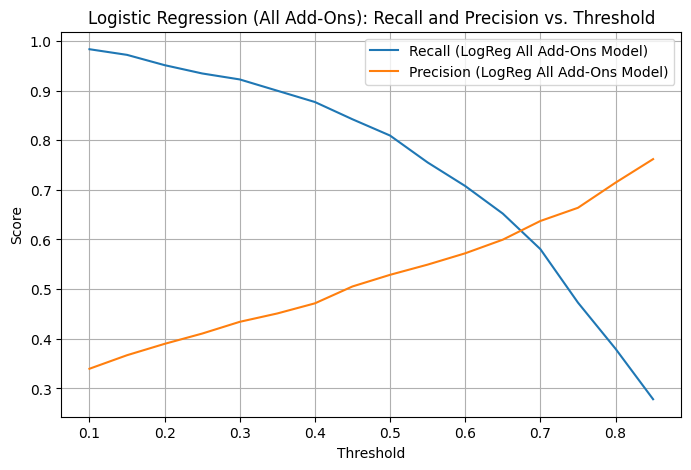

Logistic Regression (All Add-Ons) thresholds:
Threshold: 0.45, Recall: 0.84, Precision: 0.51, ROC-AUC: 0.77
Threshold: 0.50, Recall: 0.81, Precision: 0.53, ROC-AUC: 0.77
Threshold: 0.55, Recall: 0.76, Precision: 0.55, ROC-AUC: 0.77
Threshold: 0.60, Recall: 0.71, Precision: 0.57, ROC-AUC: 0.76


In [61]:
# Test probability thresholds for Logistic Regression All Add-Ons model

# Get out-of-fold predicted probabilities for the positive class
cv_pred_proba_logreg_all_add_ons = cross_val_predict(best_logreg_all_add_ons, X_train_all_add_ons, y_train, cv=5, method='predict_proba')[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)
recalls_logreg_all_add_ons = []
precisions_logreg_all_add_ons = []
roc_auc_all_add_ons = []

for thresh in thresholds:
    y_pred = (cv_pred_proba_logreg_all_add_ons >= thresh).astype(int)
    recalls_logreg_all_add_ons.append(recall_score(y_train, y_pred))
    precisions_logreg_all_add_ons.append(precision_score(y_train, y_pred))
    roc_auc_all_add_ons.append(roc_auc_score(y_train, y_pred))

plt.figure(figsize=(8,5))
plt.plot(thresholds, recalls_logreg_all_add_ons, label='Recall (LogReg All Add-Ons Model)')
plt.plot(thresholds, precisions_logreg_all_add_ons, label='Precision (LogReg All Add-Ons Model)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Logistic Regression (All Add-Ons): Recall and Precision vs. Threshold')
plt.legend()
plt.grid(True)
plt.savefig('../reports/figures/logreg_all_add_ons_thresholds.png', bbox_inches='tight', dpi=300)
plt.show()

# Print thresholds with recall ≥ 0.70 and precision ≥ 0.50
print('Logistic Regression (All Add-Ons) thresholds:')
for thresh, rec, prec, roc_auc in zip(thresholds, recalls_logreg_all_add_ons, precisions_logreg_all_add_ons, roc_auc_all_add_ons):
    if rec >= 0.70 and prec >= 0.50:
        print(f"Threshold: {thresh:.2f}, Recall: {rec:.2f}, Precision: {prec:.2f}, ROC-AUC: {roc_auc:.2f}")



### Threshold Comparison Table: Recall and Precision for Logistic Regression All Add-Ons Model with recall >= 0.7 and precision >= 0.5 (Sorted by Threshold)
| Threshold | Recall | Precision |
|-----------|--------|-----------|
| 0.50      | 0.80   | 0.52      |
| 0.55      | 0.76   | 0.55      |
| 0.60      | 0.71   | 0.57      |


In [30]:
# Calculate confusion matrix for 0.5 threshold on training data for Logistic Regression All Add-Ons Model

best_logreg_all_add_ons.fit(X_train_all_add_ons, y_train)
y_proba_logreg_train = best_logreg_all_add_ons.predict_proba(X_train_all_add_ons)[:, 1]
y_pred_logreg_train = (y_proba_logreg_train >= 0.5).astype(int)
cm_logreg_train_all_add_ons = confusion_matrix(y_train, y_pred_logreg_train)
print("Confusion Matrix - Logistic Regression (All Add-Ons, 0.5 threshold, training data):\n", cm_logreg_train_all_add_ons)





Confusion Matrix - Logistic Regression (All Add-Ons, 0.5 threshold, training data):
 [[3051 1079]
 [ 273 1222]]


In [31]:
# Confusion Matrix with Row_Wise Percentages
cm_log_reg_train_all_add_ons = confusion_matrix(y_train, y_pred_logreg_train)
cm_normalized = cm_logreg_train_all_add_ons.astype('float') / cm_logreg_train_all_add_ons.sum(axis=1)[:, np.newaxis]

cm_df_all_add_ons = pd.DataFrame(
    cm_normalized,
    index=['Actual Negative', 'Actual Positive'],
    columns=['Predicted Negative', 'Predicted Positive']
)

print('Row-normalized confusion matrix for All Add-Ons Model:')
display(cm_df_all_add_ons)

Row-normalized confusion matrix for All Add-Ons Model:


,Predicted Negative,Predicted Positive
Actual Negative,0.738741,0.261259
Actual Positive,0.182609,0.817391


**Notes:**

Businesses typically aim to identify at least 70% of actual churners (recall ≥ 0.7) and prefer that at least half of the customers flagged as churners actually do churn (precision ≥ 0.5). I focused on the threshold that met these criteria, which is why the 0.5 probability threshold was selected for evaluation. 

In practice, the optimal model choice may depend on additional business factors, such as the relative costs of customer churn versus retention offers, which are not specified here.

## 6. Final Model Testing
- Retrain final model on entire training dataset using best hyperparameters and preprocessing
- Evaluate on untouched test set
- Report final metrics (recall, precision, ROC-AUC)


### Retrain Logistic Regression All Add-Ons model on full training data with best hyperparameters

In [32]:
# Best parameters: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}

final_logreg_all_add_ons = LogisticRegression(
    **internet_service_grid.best_params_,
    max_iter=1000,
    random_state=SEED
)
final_logreg_all_add_ons.fit(X_train_all_add_ons, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


### Predict on All Add-Ons test set and apply threshold

In [33]:
# Predictions on test set
X_test_all_add_ons = X_test_final_clean[pruned_features_all_add_ons]

y_pred_final_logreg_all_add_ons = final_logreg_all_add_ons.predict(X_test_all_add_ons)
y_proba_final_logreg_all_add_ons = final_logreg_all_add_ons.predict_proba(X_test_all_add_ons)[:, 1]


# Apply 0.5 threshold
y_pred_final_logreg_all_add_ons = (y_proba_final_logreg_all_add_ons >= 0.5).astype(int)

### Evaluate Internet Service Logistic Regression model on test set

In [34]:
# Compare predictions to true labels--All Add-Ons Model
recall_all_add_ons = recall_score(y_test, y_pred_final_logreg_all_add_ons)
precision_all_add_ons = precision_score(y_test, y_pred_final_logreg_all_add_ons)
roc_auc_all_add_ons = roc_auc_score(y_test, y_proba_final_logreg_all_add_ons)
cm_all_add_ons = confusion_matrix(y_test, y_pred_final_logreg_all_add_ons)

print(f"Recall Final All Add-Ons Model: {recall_all_add_ons:.3f}")
print(f"Precision Final All Add-Ons Model: {precision_all_add_ons:.3f}")
print(f"ROC-AUC Final All Add-Ons Model: {roc_auc_all_add_ons:.3f}")
print("Confusion Matrix Final All Add-Ons Model:")
print(cm_all_add_ons)

Recall Final All Add-Ons Model: 0.797
Precision Final All Add-Ons Model: 0.492
ROC-AUC Final All Add-Ons Model: 0.835
Confusion Matrix Final All Add-Ons Model:
[[725 308]
 [ 76 298]]


### Display row-normalized confusion matrix for All Add-Ons logistic regression model

In [35]:
def confusion_matrix_percentages(cm):
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    return pd.DataFrame(
        cm_pct,
        index=['Actual Negative', 'Actual Positive'],
        columns=['Predicted Negative', 'Predicted Positive']
    )

cm_pct_all_add_ons = confusion_matrix_percentages(cm_all_add_ons)

print("Confusion Matrix (% actual class, row-normalized) - Final All Add-Ons Logistic Regression (0.5 threshold, test set):")
display(cm_pct_all_add_ons)

Confusion Matrix (% actual class, row-normalized) - Final All Add-Ons Logistic Regression (0.5 threshold, test set):


,Predicted Negative,Predicted Positive
Actual Negative,70.183930,29.816070
Actual Positive,20.320856,79.679144


### Comparison of Validation and Test Set Performance for Final Logistic Regression Model

The table below summarizes key metrics at the 0.50 probability threshold, comparing the model’s performance on the validation set (cross-validated training data) to its performance on the holdout test set after retraining on the full training data. This allows for an assessment of model generalization and consistency across data splits.

**Note on terminology:**
- The "validation set" refers to the portion of the training data used during cross-validation to tune hyperparameters and select the best model. These results reflect model performance during development, before seeing the test set.
- The "test set" (also called the holdout set) is a separate, untouched dataset set aside at the start of the project. It is only used for the final evaluation after all model selection and tuning are complete, providing an unbiased estimate of real-world performance.

**Table of Validation and Test Set Metrics**

| Metric                                | Validation Set | Test Set |
|---------------------------------------|----------------|----------|
|Recall                                 | 0.8094            | 0.797     |
|Precision                              | 0.5290            | 0.492     |
|ROC-AUC                                | 0.8469           | 0.835    |
|Confusion Matrix (% of actual class)   |                 |          |
|    - True Neg (TN)                    | 73.9           | 70.18      |
|    - False Pos (FP)                   | 26.1           | 29.82      |
|    - False Neg (FN)                   | 18.26           | 20.32      |
|    - True Pos (TP)                    | 81.74           | 79.68      |

**Summary**:
- The model generalizes well—there’s no sign of severe overfitting.
- The small drop in precision and recall is expected when moving from validation to test data.
- These differences are minor and within the range of normal variation.


### Determine the most important features for final Internet Service logistic regression model

In [36]:
# Determine most important predictors for final Internet Service logistic regression model

# Get feature names and coefficients
feature_names_all_add_ons = X_train_all_add_ons.columns
coefs_all_add_ons = final_logreg_all_add_ons.coef_.flatten()

# Create DataFrame of features and coefficients
coef_df_all_add_ons = pd.DataFrame({
    'feature': feature_names_all_add_ons,
    'coefficient': coefs_all_add_ons,
    'abs_coefficient': np.abs(coefs_all_add_ons)
})

# Sort by absolute value of coefficient (importance)
coef_df_all_add_ons = coef_df_all_add_ons.sort_values('abs_coefficient', ascending=False)

In [53]:
# Load the column manifest with readable labels
manifest = pd.read_csv('../references/telco_column_role_manifest_with_labels.csv')

# Create a mapping: feature code → readable label
# Adjust column names as needed based on your manifest structure
feature_map = dict(zip(manifest['column_name'], manifest['readable_label']))

# Map features in coef_df to readable labels
coef_df_all_add_ons['readable_label'] = coef_df_all_add_ons['feature'].map(feature_map).fillna(coef_df_all_add_ons['feature'])

# Display top predictors with readable labels
print(coef_df_all_add_ons[['readable_label', 'coefficient', 'abs_coefficient']].head(10))

# Save the top predictors with readable labels as a CSV file
coef_df_all_add_ons[['readable_label', 'coefficient', 'abs_coefficient']].to_csv(
    '../reports/top_predictors_logreg_all_add_ons.csv', index=False
)

                     readable_label  coefficient  abs_coefficient
18                Contract_Two_year    -1.796906         1.796906
25        Tenure Group (49+ months)    -1.691383         1.691383
24      Tenure Group (25-48 months)    -1.486179         1.486179
23     Tenure Group (13-24  months)    -1.129718         1.129718
4    Internet Service (Fiber Optic)     0.896279         0.896279
17            Contract 1-year (Yes)    -0.873276         0.873276
26       Tenure Group (7-12 months)    -0.765763         0.765763
21  Payment Method Electronic (Yes)     0.406199         0.406199
6             Online Security (Yes)    -0.372610         0.372610
3              Multiple Lines (Yes)     0.353136         0.353136


/var/folders/xk/1_94y7fn37sf7kbch2g77hlm0000gp/T/ipykernel_90977/1520250730.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='coefficient', y='readable_label', data=top_coef, palette='coolwarm', orient='h')


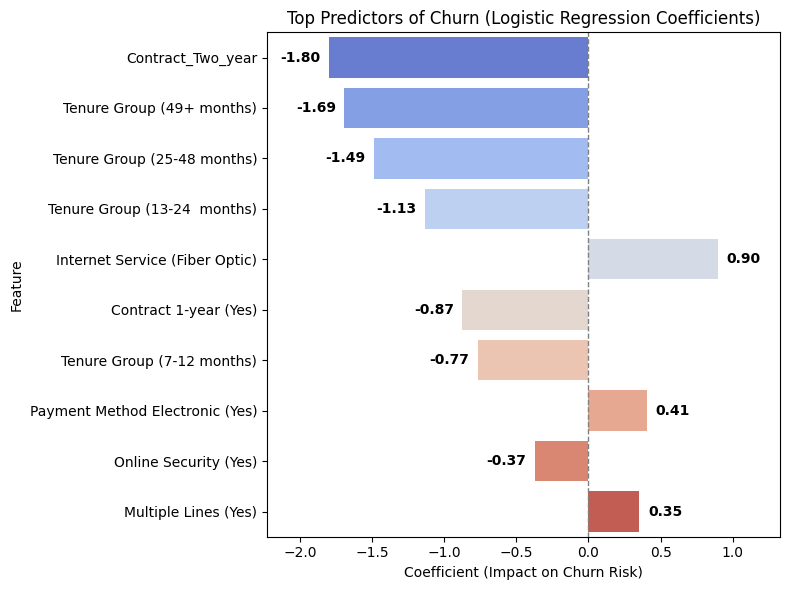

In [54]:
# Plot top predictors for churn from logistic regression model

top_n = 10
top_coef = coef_df_all_add_ons.head(top_n).copy()
plt.figure(figsize=(8, 6))  # Wide figure for more space
ax = sns.barplot(x='coefficient', y='readable_label', data=top_coef, palette='coolwarm', orient='h')
plt.title('Top Predictors of Churn (Logistic Regression Coefficients)')
plt.xlabel('Coefficient (Impact on Churn Risk)')
plt.ylabel('Feature')
plt.axvline(0, color='gray', linestyle='--', linewidth=1)

# Set x-limits to add more space for annotation text
xlim = ax.get_xlim()
x_pad = 0.1 * (xlim[1] - xlim[0])
plt.xlim(xlim[0] - x_pad, xlim[1] + x_pad)

# Annotate each bar with its coefficient value, always outside the bar
for bar, coef in zip(ax.patches, top_coef['coefficient']):
    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    if x >= 0:
        text_x = x + 0.02 * (xlim[1] - xlim[0])
        ha = 'left'
    else:
        text_x = x - 0.02 * (xlim[1] - xlim[0])
        ha = 'right'
    ax.text(text_x, y, f'{coef:.2f}', va='center', ha=ha, color='black', fontsize=10, fontweight='bold', clip_on=False)

plt.tight_layout()
plt.savefig('../reports/figures/top_predictors_logreg_all_add_ons.png', bbox_inches='tight', dpi=300)
plt.show()

## 7. Interpretation of top coefficients
Of the top 10 predictors of churn, seven are negative—these are key retention factors. The remaining three are positive, indicating that customers with these characteristics are more likely to churn. It is common for churn models to identify more strong retention factors (negative coefficients) than churn factors (positive coefficients), since many features are designed to reduce churn risk, while actual churn is often triggered by a few specific issues such as high prices or poor service.

**Retention Factors**

In the final Logistic Regression All Add-Ons model, several factors stood out as most important for customer retention. As expected, customers with longer contract terms (1-year and 2-year contracts) and those who have been with the company for a longer period (tenure groups: 7-12 months, 13-24 months, 25-48 months, and 48+ months) were much less likely to churn. This makes sense because longer contracts and higher tenure typically indicate greater customer commitment and satisfaction.

The Online Security add-on service also emerged as a significant retention factor, showing the largest effect among all the add-on services. One possible explanation is that the Online Security service addresses specific customer concerns (such as data protection or internet safety), making them more satisfied and less likely to churn.

In summary, while contract length and tenure are classic retention drivers, the strong association between the Online Security add-on and lower churn highlights the importance of value-added services in customer retention strategies.

**Churn Factors**

The primary factors associated with customer churn are fiber optic internet service, electronic payment method, and multiple phone lines. These factors are distinct and likely represent different customer segments.

Fiber optic internet service relates to the type of internet technology a customer uses. Since fiber is typically marketed as a premium, high-speed option, customers who choose it often have higher expectations for reliability and performance. If their experience falls short, they may be more inclined to switch providers.

Electronic payment method refers to how customers pay for their service. The convenience and flexibility of electronic payments make it easier for customers to cancel or switch providers. Those comfortable with digital transactions may be more likely to change services when dissatisfied.

Multiple phone lines indicate a more complex or larger account, such as families or businesses. Customers managing several lines are often more attentive to costs and service quality, making them more proactive in seeking better deals or switching providers if issues arise.

To summarize, these churn factors—fiber optic internet service, electronic payment method, and multiple phone lines—reflect different aspects of customer behavior and needs. Their influence on churn highlights the importance of understanding diverse customer segments and tailoring retention strategies accordingly.



## 8. Documentation

**Model Selection Rationale and Business Implications**

The final model was chosen for its strong recall and ROC-AUC scores, emphasizing the ability to accurately identify customers at risk of churning. Recall was priorized to identify as many customers at risk of churning as possible (minimizing false negatives). This approach is especially important for the business, as failing to identify a customer likely to churn can result in lost revenue and missed opportunities for retention.

Logistic Regression was selected due to its interpretability, which makes it easier to communicate key drivers to business stakeholders. Although advanced LightGBM models were also tested, they did not outperform Logistic Regression. By incorporating both classic retention factors (such as contract length and tenure) and actionable service features (like the Online Security add-on), the model provides recommendations that are both data-driven and directly relevant to business needs.

From a business perspective, the model enables targeted retention strategies by identifying high-risk customers and the specific factors influencing their likelihood to churn. This supports more efficient allocation of retention resources and the design of tailored offers or interventions.

In the future, additional features or external data sources could be explored to improve predictive power.


## 9. Outputs
Save all relevant figures, tables, and processed data to the appropriate folders.

In [39]:
# Save processed datasets with cleaned column names for LightGBM
X_train_final_clean.to_csv('../data/processed/X_train_final_clean.csv', index=False)
X_test_final_clean.to_csv('../data/processed/X_test_final_clean.csv', index=False)
X_train_all_add_ons.to_csv('../data/processed/X_train_all_add_ons.csv', index=False)

# Save extracted target variables
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

In [55]:
# Create the model performance summary as a DataFrame
model_performance = pd.DataFrame({
    "Model": [
        "Logistic Regression: All Features",
        "Logistic Regression: Monthly Charges",
        "Logistic Regression: Internet Service",
        "Logistic Regression: All Add-Ons",
        "LightGBM: All Features",
        "LightGBM: Monthly Charges",
        "LightGBM: Internet Service",
        "LightGBM: All Add-Ons"
    ],
    "Recall": [0.802, 0.800, 0.804, 0.8094, 0.7973, 0.8181, 0.8013, 0.8054],
    "Precision": [0.5262, 0.5163, 0.5227, 0.5290, 0.5263, 0.497, 0.5117, 0.5195],
    "ROC-AUC": [0.8479, 0.8339, 0.8445, 0.8469, 0.8428, 0.8356, 0.8402, 0.8431]
})

# Save the DataFrame as a CSV file
model_performance.to_csv('../reports/model_performance_summary.csv', index=False)

model_performance

,Model,Recall,Precision,ROC-AUC
0,Logistic Regression: All Features,0.8020,0.5262,0.8479
1,Logistic Regression: Monthly Charges,0.8000,0.5163,0.8339
2,Logistic Regression: Internet Service,0.8040,0.5227,0.8445
3,Logistic Regression: All Add-Ons,0.8094,0.5290,0.8469
4,LightGBM: All Features,0.7973,0.5263,0.8428
5,LightGBM: Monthly Charges,0.8181,0.4970,0.8356
6,LightGBM: Internet Service,0.8013,0.5117,0.8402
7,LightGBM: All Add-Ons,0.8054,0.5195,0.8431


In [67]:
# Create the validation and test set metrics table as a DataFrame
table_metrics = pd.DataFrame({
    'Metric': [
        'Recall',
        'Precision',
        'ROC-AUC',
     ],
    'Validation Set': [
        0.8094,
        0.5290,
        0.8469,
    ],
    'Test Set': [
        0.797,
        0.492,
        0.835,
    ]
})

# Save the DataFrame as a CSV file for future use
table_metrics.to_csv('../reports/validation_test_metrics_summary.csv', index=False)

table_metrics

,Metric,Validation Set,Test Set
0,Recall,0.8094,0.797
1,Precision,0.5290,0.492
2,ROC-AUC,0.8469,0.835


In [ ]:
# Create DataFrame for the confusion matrix metrics
confusion_matrix_metrics = pd.DataFrame({
    'Metric': ['True Neg (TN)', 'False Pos (FP)', 'False Neg (FN)', 'True Pos (TP)'],
    'Validation Set': [73.9, 26.1, 18.26, 81.74],
    'Test Set': [70.18, 29.82, 20.32, 79.68]
})

# Save the confusion matrix DataFrame as a CSV file
confusion_matrix_metrics.to_csv('../reports/confusion_matrix_metrics.csv', index=False)

confusion_matrix_metrics

,Metric,Validation Set,Test Set
0,True Neg (TN),73.90,70.18
1,False Pos (FP),26.10,29.82
2,False Neg (FN),18.26,20.32
3,True Pos (TP),81.74,79.68


In [62]:
# Create DataFrame for Logistic Regression (All Add-Ons) thresholds
thresholds_df = pd.DataFrame({
    'Threshold': [0.45, 0.50, 0.55, 0.60],
    'Recall': [0.84, 0.81, 0.76, 0.71],
    'Precision': [0.51, 0.53, 0.55, 0.57],
    'ROC-AUC': [0.77, 0.77, 0.77, 0.76]
})

# Save as CSV
thresholds_df.to_csv('../reports/logreg_all_add_ons_thresholds_summary.csv', index=False)
thresholds_df

,Threshold,Recall,Precision,ROC-AUC
0,0.45,0.84,0.51,0.77
1,0.50,0.81,0.53,0.77
2,0.55,0.76,0.55,0.77
3,0.60,0.71,0.57,0.76


In [64]:
# Create confusion matrix table for Logistic Regression (All Add-Ons, 0.5 threshold, training data)
conf_matrix_train = pd.DataFrame({
    'Actual': ['Negative', 'Positive'],
    'Predicted Negative': [0.738741, 0.182609],
    'Predicted Positive': [0.261259, 0.817391]
})

# Save as CSV
conf_matrix_train.to_csv('../reports/cm_logreg_all_add_ons_train_0.5_row_norm.csv', index=False)
conf_matrix_train

,Actual,Predicted Negative,Predicted Positive
0,Negative,0.738741,0.261259
1,Positive,0.182609,0.817391


In [65]:
# Fit and predict as in your code
best_logreg_all_add_ons.fit(X_train_all_add_ons, y_train)
y_proba_logreg_train = best_logreg_all_add_ons.predict_proba(X_train_all_add_ons)[:, 1]
y_pred_logreg_train = (y_proba_logreg_train >= 0.5).astype(int)
cm_logreg_train_all_add_ons = confusion_matrix(y_train, y_pred_logreg_train)

# Convert raw confusion matrix to DataFrame and save as CSV
cm_raw_df = pd.DataFrame(
    cm_logreg_train_all_add_ons,
    index=['Actual Negative', 'Actual Positive'],
    columns=['Predicted Negative', 'Predicted Positive']
)
cm_raw_df.to_csv('../reports/conf_matrix_logreg_all_add_ons_train_0.5_raw.csv')
cm_raw_df

,Predicted Negative,Predicted Positive
Actual Negative,3051,1079
Actual Positive,273,1222
